<a href="https://colab.research.google.com/github/ShyamSundhar1411/My-ML-Notebooks/blob/master/LangGraph/Graph_Building_Exercises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from typing import Dict, TypedDict
from langgraph.graph import StateGraph

## Hello World Agent

In [2]:
class AgentState(TypedDict): # State Schema
  message: str

def greeting_node(state: AgentState) -> AgentState:
  """
    Simple node that adds a greeting message to the state
  """
  state["message"] = "Hey"+state["message"]+", how is your day going"
  return state


In [4]:
graph = StateGraph(AgentState)
graph.add_node(
    "greeter",
    greeting_node
)
graph.set_entry_point("greeter")
graph.set_finish_point("greeter")
app = graph.compile()

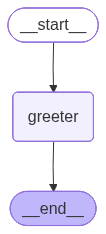

In [5]:
from IPython.display import Image,display
display(Image(app.get_graph().draw_mermaid_png()))

In [6]:
result = app.invoke({"message":"Bob"})

In [7]:
result

{'message': 'HeyBob, how is your day going'}

In [8]:
result["message"]

'HeyBob, how is your day going'

## Compliment Agent


In [10]:
class AgentState(TypedDict):
  name: str
def compliment_node(state:AgentState)->AgentState:
  """
    Node that compliments a user
  """
  state["name"] = state["name"]+", you're doing an amazing job learning LangGraph!"
  return state

In [12]:
graph = StateGraph(AgentState)
graph.add_node(
    "complimenter",
    compliment_node
)
graph.set_entry_point(
    "complimenter"
)
graph.set_finish_point(
    "complimenter"
)
app = graph.compile()

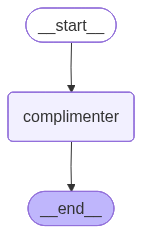

In [13]:
from IPython.display import Image,display
display(Image(app.get_graph().draw_mermaid_png()))

In [15]:
result = app.invoke({"name":"Bob"})

In [16]:
result

{'name': "Bob, you're doing an amazing job learning LangGraph!"}

## Multi Input Graphs

### Adder

In [20]:
from typing import List, TypedDict

In [21]:
class AgentState(TypedDict):
  values: List[int]
  name: str
  result: str

In [23]:
def process_values(state:AgentState)->AgentState:
  """
  A simple node that processes the list of integers and other inputs
  """
  state["result"] = f"Hi there {state["name"]}! The sum of the values is {sum(state["values"])}"
  return state

In [26]:
graph = StateGraph(AgentState)
graph.add_node(
    "processor",
    process_values
)
graph.set_entry_point("processor")
graph.set_finish_point("processor")
app = graph.compile()

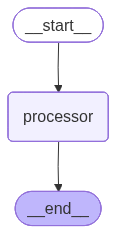

In [27]:
from IPython.display import Image,display
display(Image(app.get_graph().draw_mermaid_png()))

In [28]:
result = app.invoke({"values":[10,20,30,40],"name":"Shyam"})

In [29]:
result

{'values': [10, 20, 30, 40],
 'name': 'Shyam',
 'result': 'Hi there Shyam! The sum of the values is 100'}

### Operation Handler

In [36]:
from typing import List,TypedDict
import math
class AgentState(TypedDict):
  name: str
  values: List[int]
  operation: str
  result: str

def operation_handler(state:AgentState)->AgentState:
  """
  A simple node that applies operations to the list
  """
  operation = state["operation"]
  if operation == "*":
    answer = math.prod(state["values"])
  else:
    answer = sum(state["values"])
  result = f"Hi {state["name"]}, Your answer is {answer}"
  state["result"] = result
  return state

In [37]:
graph = StateGraph(AgentState)
graph.add_node(
    "operation_handler",
    operation_handler
)
graph.set_entry_point("operation_handler")
graph.set_finish_point("operation_handler")
app = graph.compile()


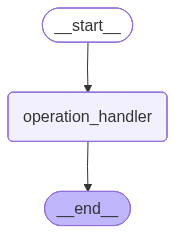

In [38]:
from IPython.display import Image,display
display(Image(app.get_graph().draw_mermaid_png()))

In [39]:
result = app.invoke({"values":[10,20,30,40],"name":"Shyam","operation":"+"})

In [40]:
result

{'name': 'Shyam',
 'values': [10, 20, 30, 40],
 'operation': '+',
 'result': 'Hi Shyam, Your answer is 100'}

In [41]:
result = app.invoke({"values":[10,20,30,40],"name":"Shyam","operation":"*"})

In [42]:
result

{'name': 'Shyam',
 'values': [10, 20, 30, 40],
 'operation': '*',
 'result': 'Hi Shyam, Your answer is 240000'}